(367, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 367 entries, 0 to 366
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            367 non-null    object 
 1   Gender             356 non-null    object 
 2   Married            367 non-null    object 
 3   Dependents         357 non-null    object 
 4   Education          367 non-null    object 
 5   Self_Employed      344 non-null    object 
 6   ApplicantIncome    367 non-null    int64  
 7   CoapplicantIncome  367 non-null    int64  
 8   LoanAmount         362 non-null    float64
 9   Loan_Amount_Term   361 non-null    float64
 10  Credit_History     338 non-null    float64
 11  Property_Area      367 non-null    object 
dtypes: float64(3), int64(2), object(7)
memory usage: 34.5+ KB
None
       ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
count       367.000000         367.000000  362.000000        361.00000

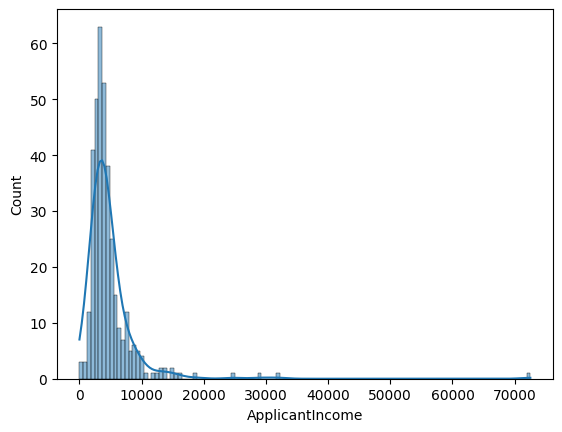

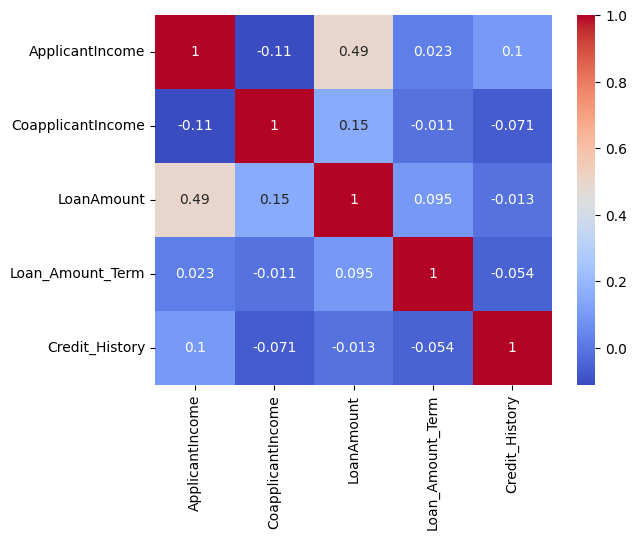

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv('test_Y3wMUE5_7gLdaTN.csv')
print(df.shape)
print(df.info())
print(df.describe())
print(df.isnull().sum())
print(df.duplicated().sum())
sns.histplot(data=df, x="ApplicantIncome", kde=True)
plt.show()
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.show()

In [15]:
print(df.columns.tolist())

['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History', 'Property_Area']


In [40]:
print("\nMissing Values:")
print(df.isnull().sum())

print("\nINSIGHT:")
print("Columns having missing values need preprocessing before model building.")


Missing Values:
Loan_ID               0
Gender               11
Married               0
Dependents           10
Education             0
Self_Employed        23
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount            5
Loan_Amount_Term      6
Credit_History       29
Property_Area         0
TotalIncome           0
dtype: int64

INSIGHT:
Columns having missing values need preprocessing before model building.


In [42]:
df.duplicated().sum()

np.int64(0)

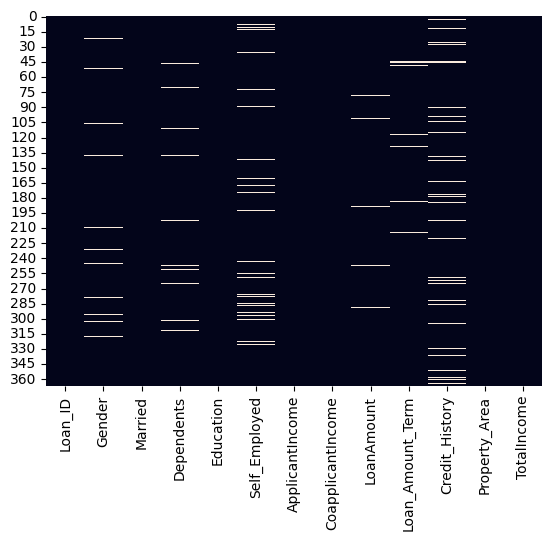

In [43]:
sns.heatmap(df.isnull(), cbar=False)
plt.show()

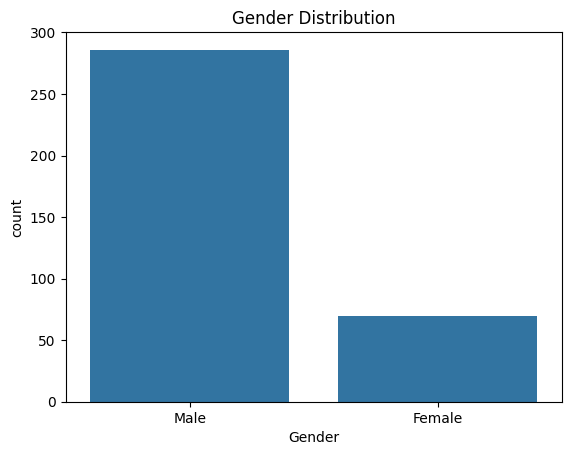

Gender
Male      286
Female     70
Name: count, dtype: int64


In [16]:
sns.countplot(data=df, x='Gender')
plt.title('Gender Distribution')
plt.show()

print(df['Gender'].value_counts())

Insights: This shows that loan applications are predominantly submitted by men, indicating a possible gender imbalance in the applicant pool.

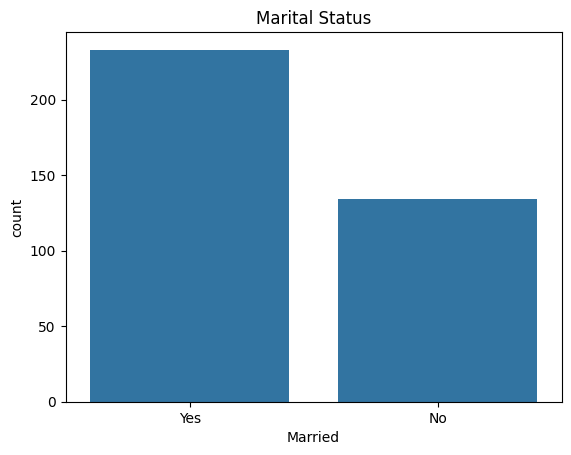

In [11]:
sns.countplot(data=df, x='Married')
plt.title('Marital Status')
plt.show()

Insights: The majority of loan applicants are married. This suggests that individuals with family responsibilities may have a greater need for financial support, leading to higher loan application rates.

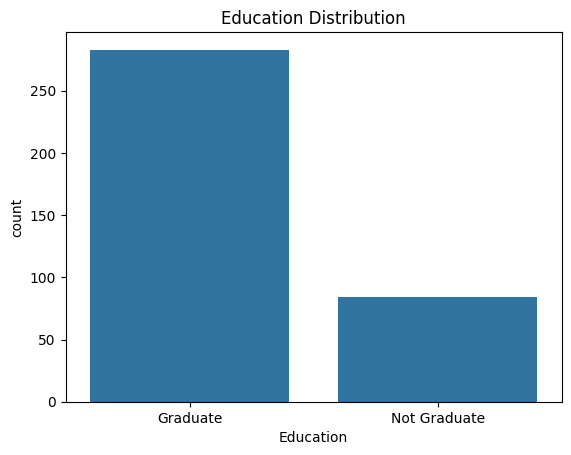

In [12]:
sns.countplot(data=df, x='Education')
plt.title('Education Distribution')
plt.show()

Insights: Graduate applicants constitute the majority of the dataset. Out of 367 applicants, 283 are graduates while only 84 are non-graduates. This suggests that individuals with higher educational qualifications are more likely to apply for loans. Graduates may have better employment opportunities and stable income sources, which can increase their confidence and eligibility for borrowing. Calculation: 283/367 ×100≈77%

Dependents
0     200
2      59
1      58
3+     40
Name: count, dtype: int64


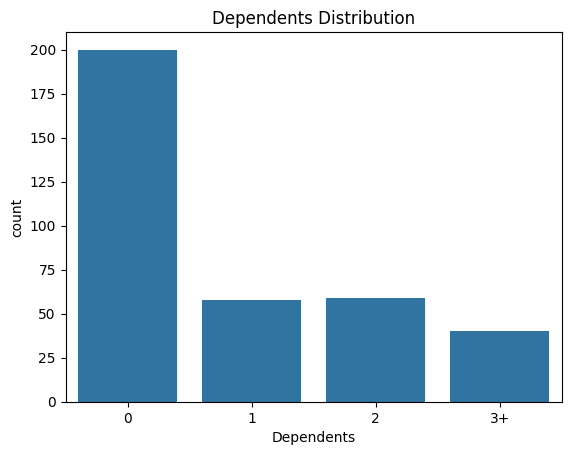

In [17]:
print(df['Dependents'].value_counts())

sns.countplot(data=df, x='Dependents')
plt.title("Dependents Distribution")
plt.show()

This suggests that most loan applicants do not have financial responsibility for dependents, which may reduce household financial burden and potentially improve repayment capacity.

Self_Employed
No     307
Yes     37
Name: count, dtype: int64


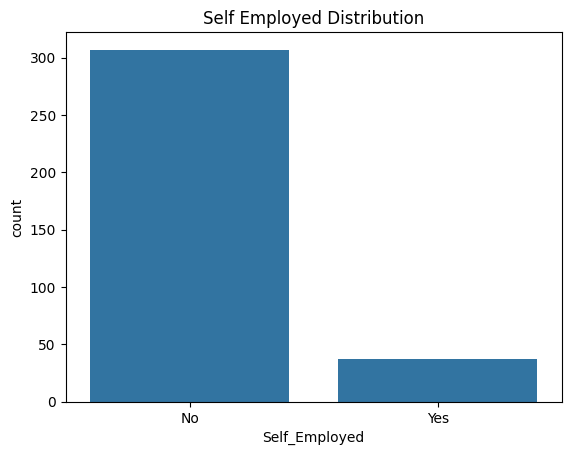

In [18]:
print(df['Self_Employed'].value_counts())

sns.countplot(data=df, x='Self_Employed')
plt.title("Self Employed Distribution")
plt.show()

The majority of applicants are not self-employed. Around 300 applicants belong to the non-self-employed category, while only a small proportion are self-employed.

Credit_History
1.0    279
0.0     59
Name: count, dtype: int64


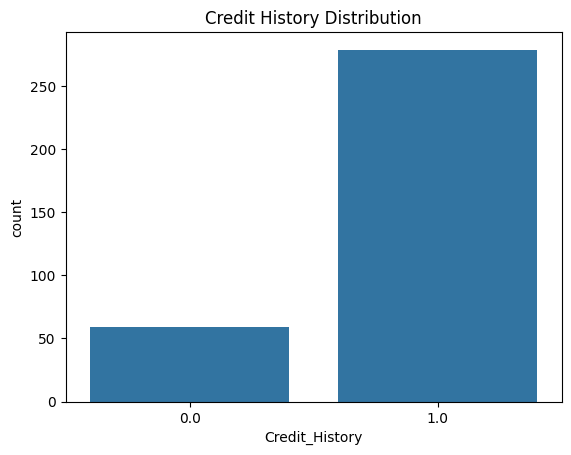

In [20]:
print(df['Credit_History'].value_counts())

sns.countplot(data=df, x='Credit_History')
plt.title("Credit History Distribution")
plt.show()

The majority of applicants have a credit history value of 1.0, while a smaller number of applicants have a credit history value of 0.0.

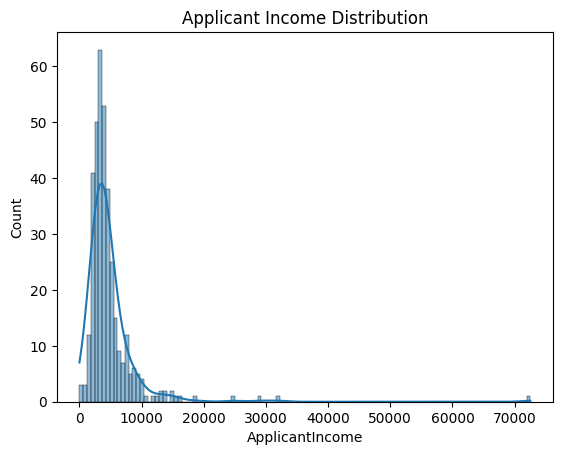

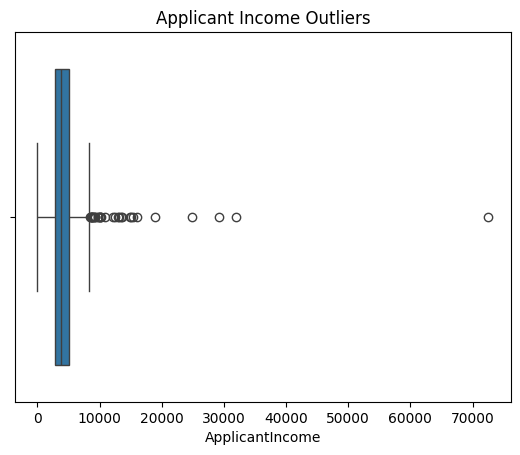

In [21]:
sns.histplot(df['ApplicantIncome'], kde=True)
plt.title("Applicant Income Distribution")
plt.show()

sns.boxplot(x=df['ApplicantIncome'])
plt.title("Applicant Income Outliers")
plt.show()

The Applicant Income distribution is positively skewed, with the majority of applicants having incomes between 0 and 1000. The boxplot also reveals several high-income outliers, indicating that while most applicants belong to the low- to moderate-income group, a small number earn significantly higher incomes than the rest.

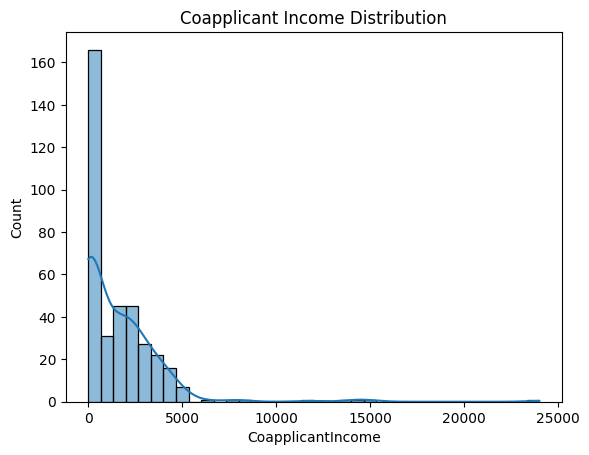

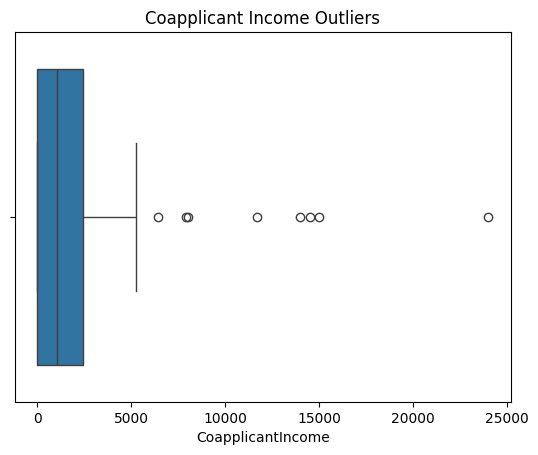

In [22]:
sns.histplot(df['CoapplicantIncome'], kde=True)
plt.title("Coapplicant Income Distribution")
plt.show()

sns.boxplot(x=df['CoapplicantIncome'])
plt.title("Coapplicant Income Outliers")
plt.show()

The majority of co-applicant income values are concentrated near 0, indicating that many applicants either do not have a co-applicant or have very little co-applicant income. The distribution is highly right-skewed.

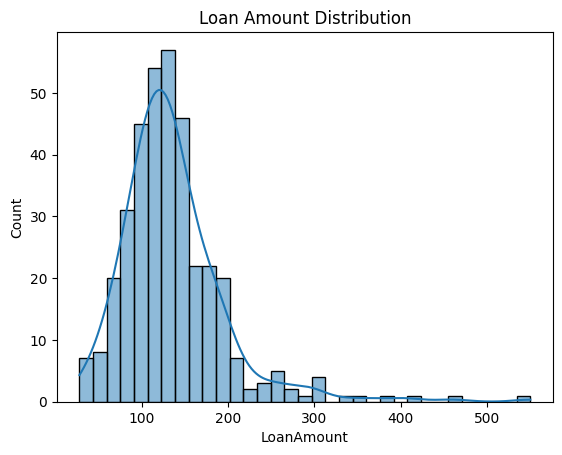

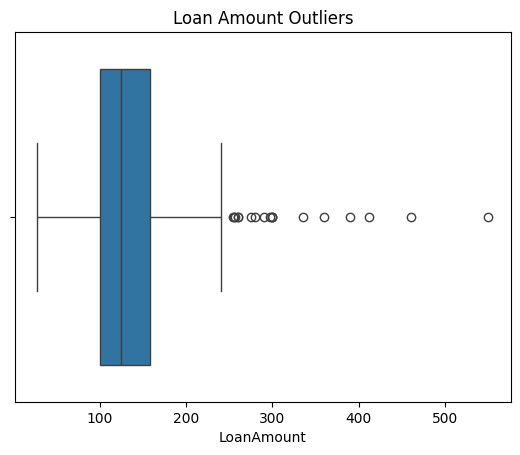

In [23]:
sns.histplot(df['LoanAmount'], kde=True)
plt.title("Loan Amount Distribution")
plt.show()

sns.boxplot(x=df['LoanAmount'])
plt.title("Loan Amount Outliers")
plt.show()

The LoanAmount distribution is positively skewed with several high-value outliers, while most loan amounts are concentrated between 80 and 180.

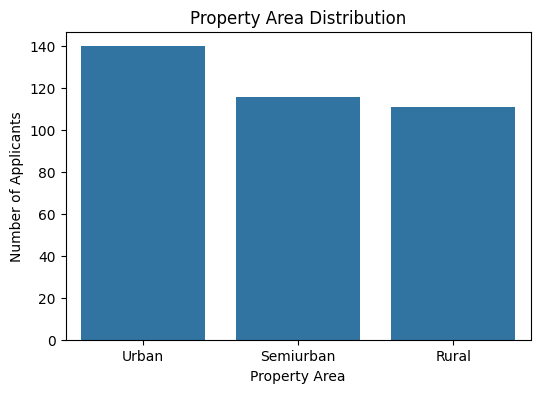

In [25]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x='Property_Area'
)

plt.title("Property Area Distribution")
plt.xlabel("Property Area")
plt.ylabel("Number of Applicants")

plt.show()

Urban areas have the highest number of loan applications, followed by Semiurban and Rural areas. This indicates that a larger proportion of applicants belong to urban regions.

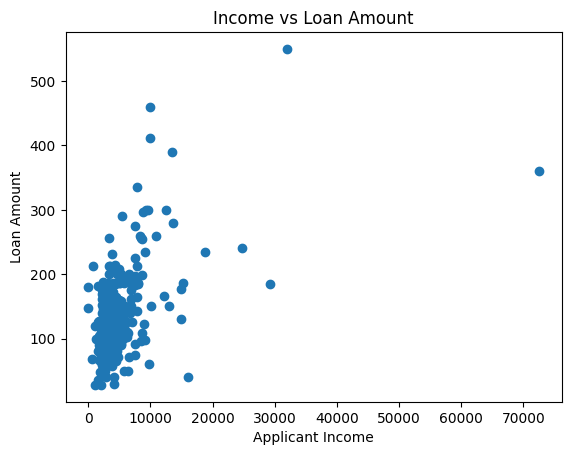


INSIGHT:
The scatter plot shows how loan amount changes with applicant income.
As income increases, loan amount generally increases.


In [27]:
plt.scatter(df["ApplicantIncome"], df["LoanAmount"])
plt.xlabel("Applicant Income")
plt.ylabel("Loan Amount")
plt.title("Income vs Loan Amount")
plt.show()

print("\nINSIGHT:")
print("The scatter plot shows how loan amount changes with applicant income.")
print("As income increases, loan amount generally increases.")

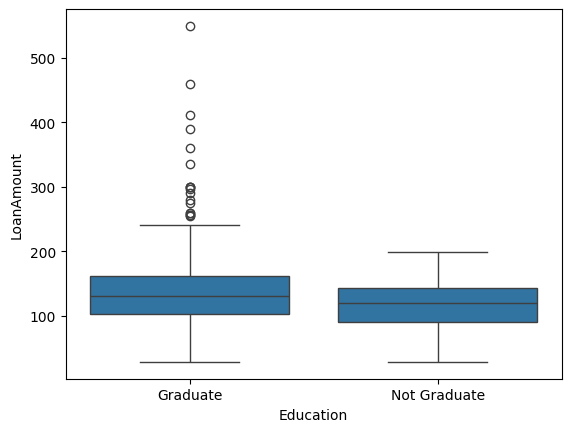

In [34]:
sns.boxplot(
    data=df,
    x='Education',
    y='LoanAmount'
)
plt.show()

Graduate applicants have a higher average loan amount compared to non-graduate applicants.

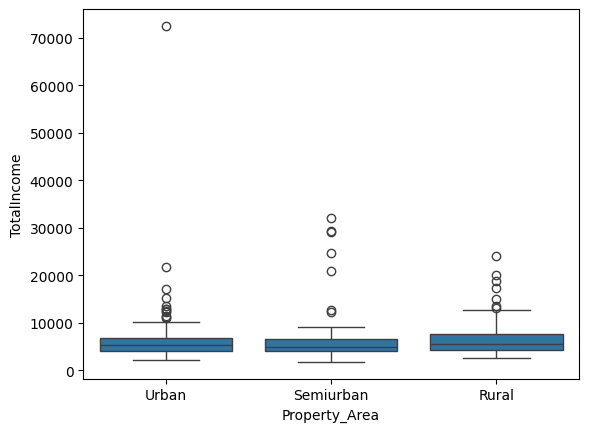

In [35]:
sns.boxplot(
    data=df,
    x='Property_Area',
    y='TotalIncome'
)
plt.show()

Rural applicants have the highest average total household income compared to applicants from Semiurban and Urban areas.

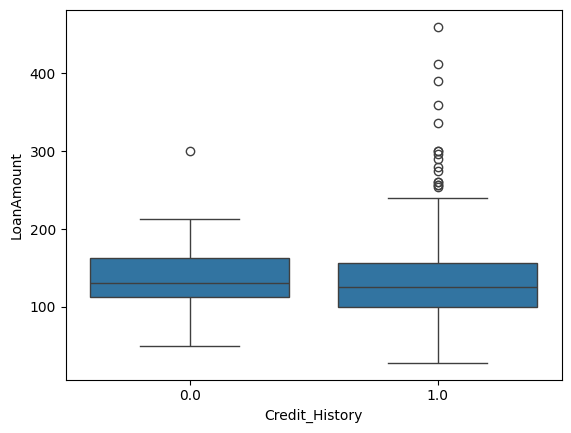

In [36]:
sns.boxplot(
    data=df,
    x='Credit_History',
    y='LoanAmount'
)
plt.show()

Applicants with no credit history (0.0) have a higher average loan amount compared to applicants with a positive credit history (1.0).

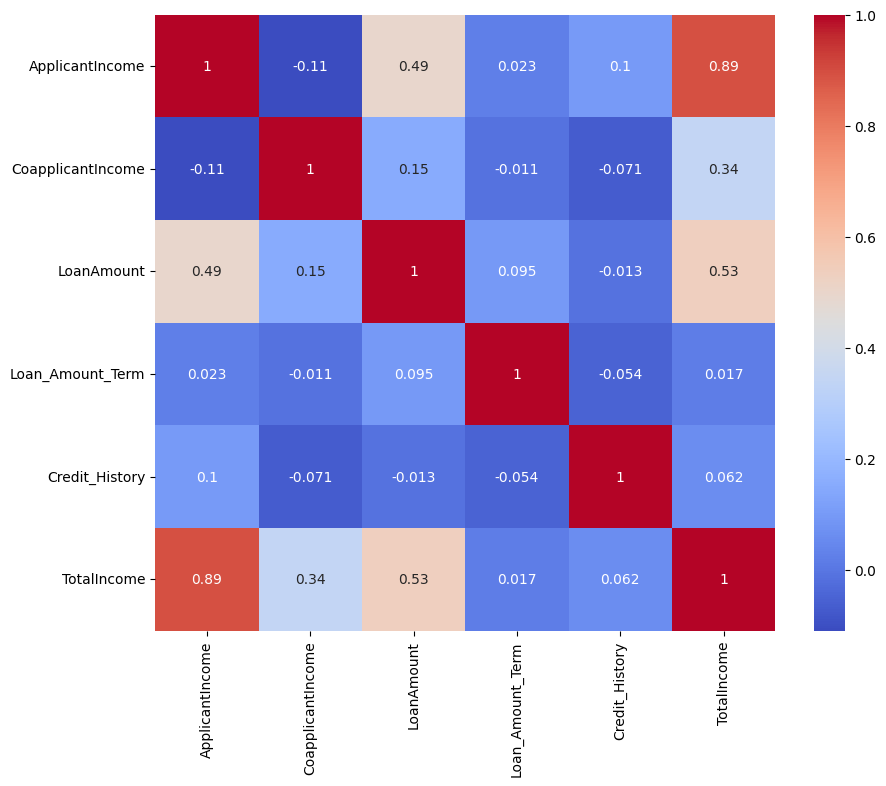

In [45]:

plt.figure(figsize=(10,8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)

plt.show()

The correlation heatmap shows the relationship between numerical variables such as ApplicantIncome, CoapplicantIncome, LoanAmount, Loan_Amount_Term, and Credit_History, TotalIncome. Most variables exhibit weak to moderate correlations, indicating that no single variable strongly influences all others.